In [1]:
%reload_ext autoreload
%autoreload 2

In [7]:
import jax
import jax.numpy as jnp

import numpy as np
import matplotlib.pyplot as plt
from dmri.simulators import Ball, Stick, Zeppelin, Dti, BallStick, Ball2Stick, AllGaussianModels
from dmri.simulators.local_signal_models.distributional_models import WatsonStick
from flax import nnx


ball_stick = AllGaussianModels.from_theta(np.random.randn(AllGaussianModels.theta_dim))

/root/simformer_model_selection/dmri/dmri/simulators/local_signal_models/distributional_models.py:40: SyntaxWarning: 'tuple' object is not callable; perhaps you missed a comma?
  signal_fn = jax.vmap(in_axes=(0, 0, None, None)(Stick.signal_fn))


In [8]:

@jax.jit
def simulator(rng):
    rng0, rng1, rng2, rng3, rng4, rng5 = jax.random.split(rng, 6)
    bvals = jax.random.choice(rng0, jnp.array(list(range(0, 2100, 100))), shape=(100,))
    bvals = jnp.sort(bvals)
    bvecs = jax.random.normal(rng3, shape=(100, 3))
    bvecs = bvecs / jnp.linalg.norm(bvecs, axis=-1, keepdims=True)
    theta = jax.random.normal(rng1, shape=(AllGaussianModels.theta_dim,))
    model_mask = jax.random.bernoulli(rng2, p=0.5, shape=(len(AllGaussianModels.model_types)))
    # This needs to have only one entry
    model_noise_idx = jax.random.randint(rng4, minval=0, maxval=len(AllGaussianModels.noise_types), shape=(1,))
    model_noise_mask = jnp.zeros(len(AllGaussianModels.noise_types), dtype=jnp.bool)
    model_noise_mask = model_noise_mask.at[model_noise_idx].set(True)
    model_mask = jnp.concatenate([model_mask, model_noise_mask], axis=-1)
    #model_mask = jnp.array([True, True, True])
    ball_stick = AllGaussianModels.from_theta(theta, model_mask=model_mask)

    x_o = ball_stick.signal(bvals, bvecs, rng=rng5)
    return model_mask, theta, x_o, bvals, bvecs


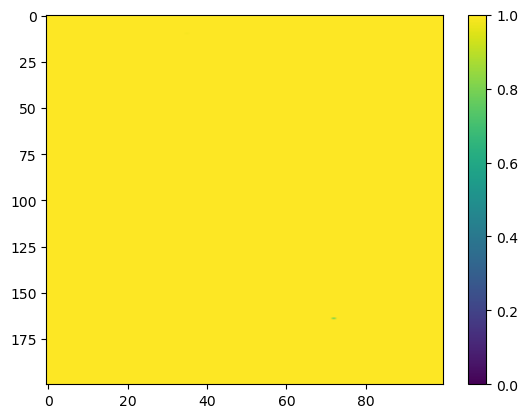

In [9]:
masks, theta, x_o, bvals, bvecs = jax.vmap(simulator)(jax.random.split(jax.random.PRNGKey(0), num=200))

plt.imshow(x_o, aspect='auto', vmin=0, vmax=1)
plt.colorbar()

In [102]:
masks.shape, theta.shape, x_o.shape, bvals.shape, bvecs.shape

((200, 18), (200, 57), (200, 100), (200, 100), (200, 100, 3))

In [103]:
from dmri.nn.dmri_reconstruction_model import DMRIInferenceModel, DMRIInferenceModelConfig

cfg = DMRIInferenceModelConfig(AllGaussianModels)

model = DMRIInferenceModel(cfg, nnx.Rngs(0))

params_encoder = nnx.state(model.encoder)
params_model_decoder = nnx.state(model.model_decoder)
params_inference_decoder = nnx.state(model.inference_decoder)

params = (params_encoder, params_model_decoder, params_inference_decoder)


In [104]:
nnx.display(model)

In [105]:
import optax


optimizer = optax.chain(optax.adaptive_grad_clip(50.), optax.adamw(5e-4))

opt_state = optimizer.init(params)


In [106]:

def loss_fn(params, data, rng):
    components, thetas,  xs, bvals, bvecs = data

    return model._loss(params[0], params[1], params[2], components, thetas, bvals, bvecs, xs, rng)


@jax.jit
def update(params, opt_state, data, rng):
    loss, grads = jax.value_and_grad(loss_fn)(params, data, rng)
    updates, opt_state = optimizer.update(grads, opt_state, params=params)
    new_params = optax.apply_updates(params, updates)
    return new_params, opt_state, loss

In [107]:
batch_simulator = jax.jit(jax.vmap(simulator))

In [108]:
key = jax.random.PRNGKey(0)
for i in range(200):
    key, subkey1 = jax.random.split(key, 2)
    masks, thetas, x_os, bvals, bevecs = batch_simulator(jax.random.split(subkey1, 2**18))
    l = 0
    for j in range(1000):
        key, subkey2 = jax.random.split(key, 2)
        idx = jax.random.randint(subkey2, (256,), 0, 2**18)
        masks_batch, thetas_batch, x_os_batch, bvals_batch, bvecs_batch = masks[idx], thetas[idx], x_os[idx], bvals[idx], bevecs[idx]
        params, opt_state, loss = update(params, opt_state, (masks_batch, thetas_batch, x_os_batch, bvals_batch, bvecs_batch), subkey2)
        l += loss
    print(l/10000)

1.665436
1.4980558
1.4902691
1.454579
1.4488189
1.4401652
1.4281665
1.4271238
1.4158628
1.4168425
1.4104545
1.4105802
1.4060143
1.4008611
1.401457
1.4032037
1.398393
1.4006212
1.3913993
1.3970424
1.3889103
1.390448
1.3922206
1.3858813
1.3841827
1.383073
1.39658
1.3805059
1.3886085
1.4004611
1.3834159
1.3854885
1.3751584
1.3726517
1.3899659
1.3797134
1.3885483
1.3672194
1.366703
1.3781836
1.3796057
1.364831
1.3760761
1.4484391
1.365614
1.3675014
1.3652802
1.3820691
1.3698646
1.4020004
1.357714
1.3604335
1.3719451
1.3495744
1.4452296
1.361321
1.3614804


Exception ignored in: <bound method IPythonKernel._clean_thread_parent_frames of <ipykernel.ipkernel.IPythonKernel object at 0x155551a21010>>
Traceback (most recent call last):
  File "/home/macke/mgloeckler90/miniconda3/envs/dipy/lib/python3.11/site-packages/ipykernel/ipkernel.py", line 775, in _clean_thread_parent_frames
    def _clean_thread_parent_frames(

KeyboardInterrupt: 


1.3665543
1.3586396
1.4101322
1.3341384
1.3595711
1.3872808
1.3698722
1.3448552
1.3637215
1.3670005
1.4479971
1.3568614
1.3521291
1.3614147
1.3479307
1.399667
1.3774388
1.3352238
1.4580743
1.3497612
1.325851
1.3309416
1.319916
1.3642751
1.3917679
1.3387274
1.4652305
1.553775
1.3228787
1.3231401
1.3543327
1.3337214
1.3428639
1.3360932
1.3789173
1.3411602
1.3587642
1.3381939
1.3732182
1.3182406
1.3249642
1.7002655
1.3385928
1.3623064
1.5674719
1.3254088
1.3212378
1.4596633
1.4150419
1.4141029
1.390664
1.3754997
1.3378385
1.3085353
1.4709985
1.3030732
1.3010087
1.2953606
1.3249861
1.3190687
1.503675
1.4098165
1.3004701
1.3205003
1.3276993
1.3115264
1.3067801
1.2939163
1.3304012
1.3346201
1.3967508
1.3031968
1.3063762
1.3013647
1.4565388
1.3356587
1.3388318
2.32166
1.2892361
1.3133297
1.3034906
1.3374075
1.4037871
1.3790284
1.3007782
1.2945018
1.3095125
1.8897747
1.3315747
1.2964753
1.3271302
1.2998955
1.9399779
1.3956736
1.3098099
1.2862706
1.3041501
1.3621056
1.3253222
1.4905188
1.787198

In [109]:
nnx.update(model.encoder, params[0])
nnx.update(model.model_decoder, params[1])
nnx.update(model.inference_decoder, params[2])

In [125]:
import pickle

with open('params_large.pkl', 'wb') as f:
    pickle.dump(params, f)

In [111]:
# import pickle
# with open('params.pkl', 'rb') as f:
#     params = pickle.load(f)
#     nnx.update(model.encoder, params[0])
#     nnx.update(model.model_decoder, params[1])
#     nnx.update(model.inference_decoder, params[2])

In [112]:
masks, thetas, x_os, bvals, bevecs = batch_simulator(jax.random.split(jax.random.key(0), 100))

In [168]:
idx = 10

In [169]:
mask = jax.vmap(model.sample_mask, in_axes=(0,None,None, None))(jax.random.split(jax.random.key(0), 128), bvals[idx], bevecs[idx], x_os[idx])

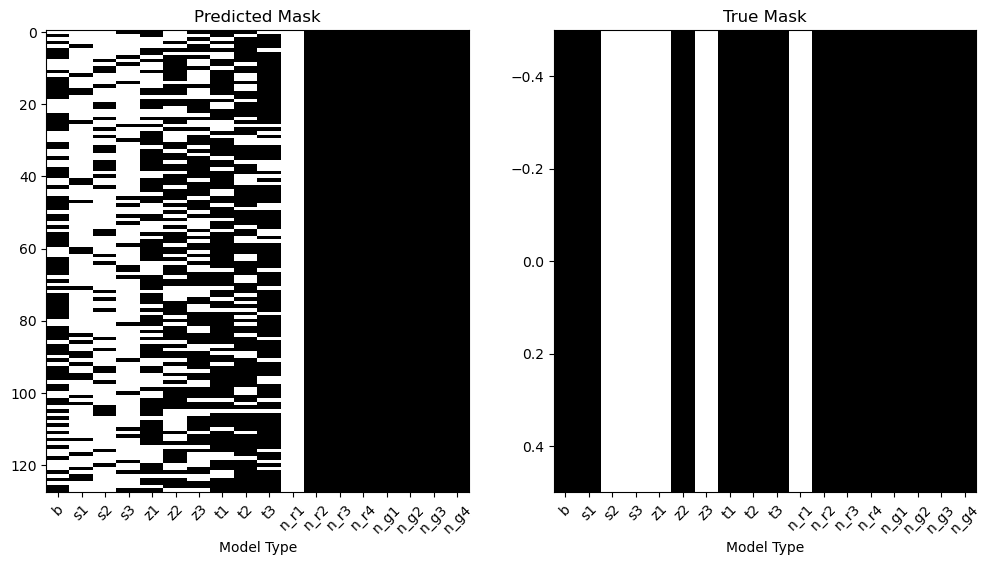

In [187]:
plt.figure(figsize=(12, 6))

# Plot predicted mask
plt.subplot(1, 2, 1)
plt.imshow(mask, aspect='auto', cmap='gray', vmin=0, vmax=1)
plt.title('Predicted Mask')
plt.xlabel('Model Type')
plt.xticks(range(len(AllGaussianModels.model_types) + len(AllGaussianModels.noise_types)), ["b", "s1","s2", "s3", "z1", "z2", "z3", "t1", "t2", "t3", "n_r1", "n_r2","n_r3", "n_r4", "n_g1", "n_g2","n_g3", "n_g4"], rotation=45)

# Plot true mask
mask_true = masks[idx]
plt.subplot(1, 2, 2)
plt.imshow(mask_true[None], aspect='auto', cmap='gray', vmin=0, vmax=1)
plt.title('True Mask')
plt.xlabel('Model Type')
plt.xticks(range(len(AllGaussianModels.model_types) + len(AllGaussianModels.noise_types)), ["b", "s1","s2", "s3", "z1", "z2", "z3", "t1", "t2", "t3", "n_r1", "n_r2","n_r3", "n_r4", "n_g1", "n_g2","n_g3", "n_g4"], rotation=45)

plt.show()

In [171]:
from functools import partial

In [176]:
thetas_post = jax.vmap(partial(model.sample_theta, num_steps=64, max_noise=40), in_axes=(0,None,None, None, None))(jax.random.split(jax.random.key(0), 1024), bvals[idx], bevecs[idx], x_os[idx],mask[idx])

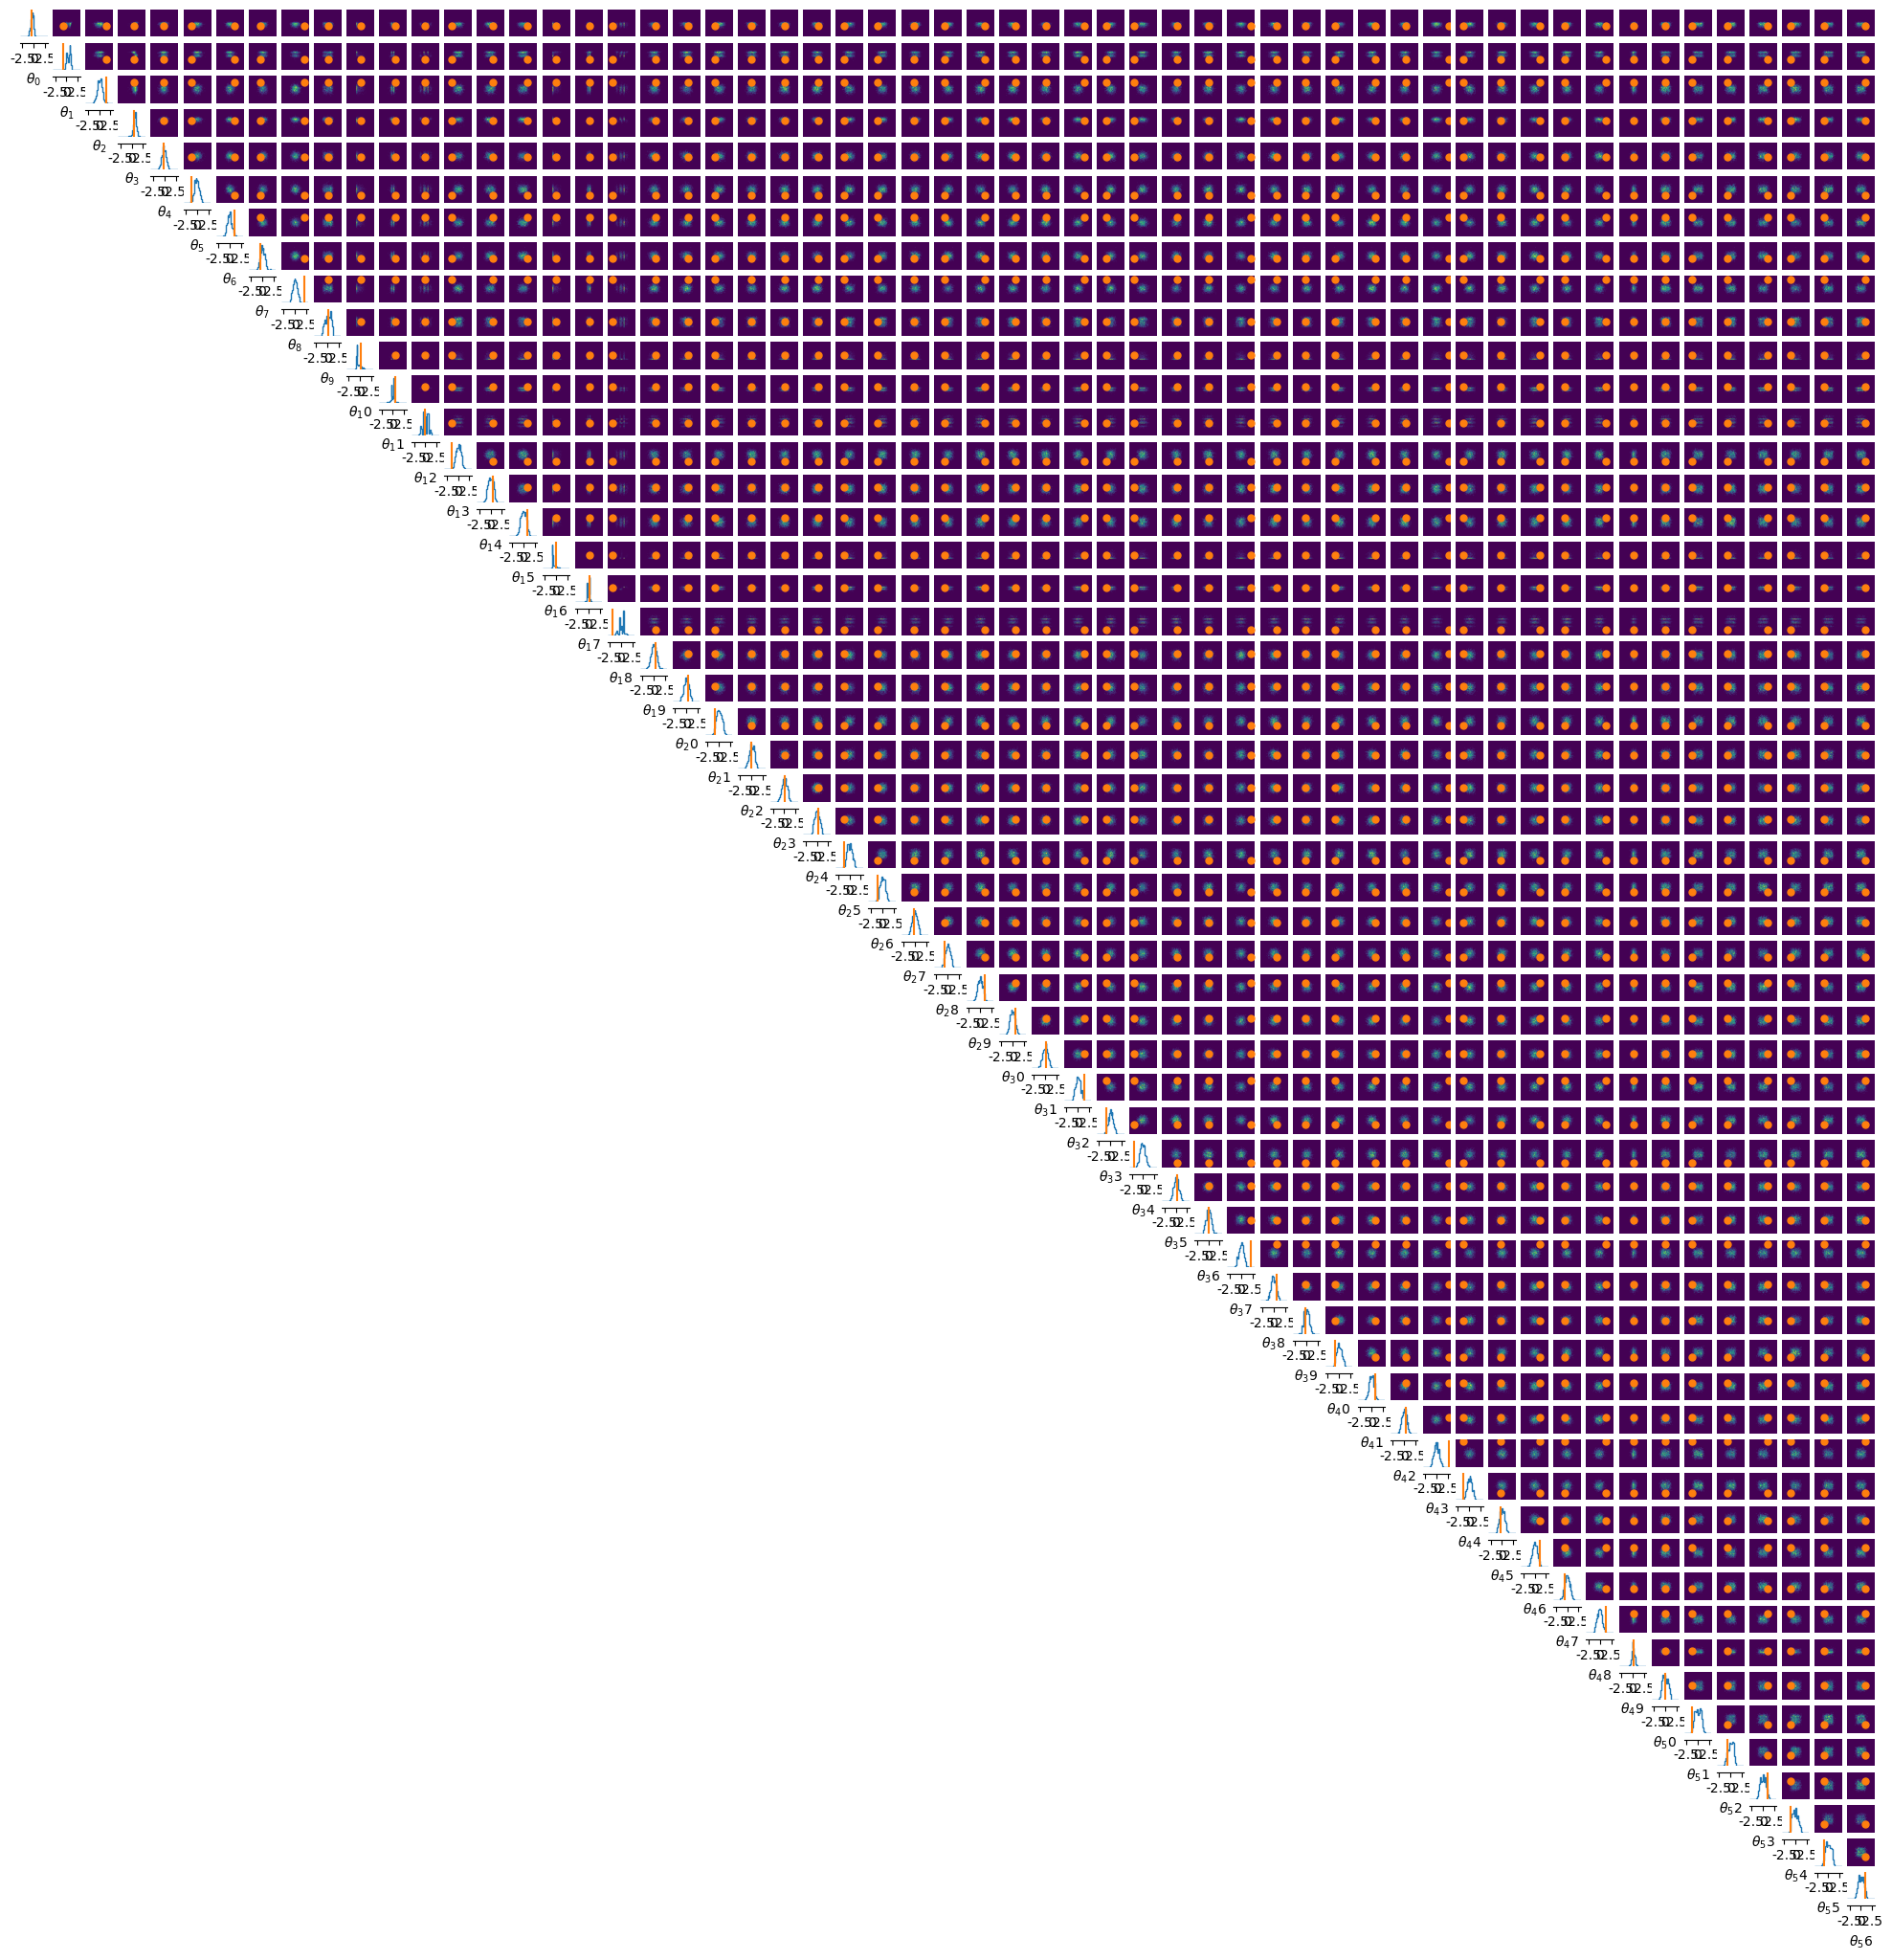

In [173]:
import sbi
from sbi.analysis.plot import pairplot

_ = pairplot(thetas_post, points=[thetas[idx],], limits=[[-3,3]*100], labels=[f'$\\theta_{i}$' for i in range(100)], figsize=(25, 25))

In [177]:
def posterior_pred(theta,rng):
    return AllGaussianModels.from_theta(theta, model_mask=mask[idx]).signal(bvals[idx], bevecs[idx], rng=rng)

posterior_preds = jax.vmap(posterior_pred)(thetas_post, jax.random.split(jax.random.key(0), 1024))

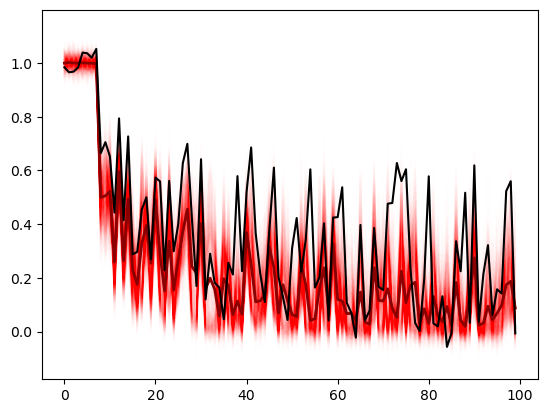

In [183]:
_ = plt.plot(posterior_preds.T, label="posterior pred", color="red", alpha=0.005)
_ = plt.plot(posterior_preds.mean(0).T, label="posterior pred mean", color="darkred", linewidth=2)
_ = plt.plot(x_os[idx], label="data", color="black")